# Part 1.A — Making GPT2 Better, One Step at a Time

Next-token prediction on the **Penn Treebank** corpus with a GPT2-style decoder-only
Transformer trained from scratch. Quality is measured by **perplexity**  the
exponentiated mean negative log-likelihood of held-out text, so lower means the model
is less surprised by the text:

$$\mathrm{PPL} = \exp\left(-\frac{1}{N}\sum_{t=1}^{N} \log p(x_t \mid x_{<t})\right)$$

Improvements are applied **one at a time**, so we can actually see what helps and what
doesn't. Each change is carried forward even if it doesn't help, which keeps the
comparison honest rather than showing only a greedy best path.

| Step | What we change |
|------|----------------|
| 0 | Find a good learning rate for AdamW |
| 1 | Scale up the model (`d_model`, `n_heads`, `num_layers`, `ff_dim`) |
| 2 | Add dropout to stop overfitting |
| 3 | Tie the input and output embeddings |

Model selection uses **dev** perplexity; the **test** split is only touched for the final
held-out evaluation. **We need PPL < 250 at every step.**

In [1]:
import math
import copy
import os
import urllib.request
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from transformers import AutoTokenizer

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# settings shared by every experiment below
BLOCK_SIZE   = 128     # maximum sequence length in tokens
N_EPOCHS     = 5
PATIENCE     = 3       # early stopping on dev PPL
WEIGHT_DECAY = 0.01    # AdamW decoupled weight decay
CLIP         = 1.0     # gradient-norm clipping

print(f'Device      : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'Block size  : {BLOCK_SIZE} tokens')
print(f'Epochs      : {N_EPOCHS} (patience {PATIENCE})')

Device      : cuda:0
GPU         : Tesla T4
Block size  : 128 tokens
Epochs      : 5 (patience 3)


## Loading the Data

Penn Treebank, loaded from the course repository. Each sentence gets an explicit `<eos>`
marker so the model knows where sentences stop. Tokenisation uses the GPT2 BPE tokenizer;
GPT2 has no padding token, so the EOS token is reused for padding and masked out of the
loss.

In [3]:
os.makedirs('dataset/PennTreeBank', exist_ok=True)
base = 'https://raw.githubusercontent.com/massimo-rizzoli/NLU-2026-Labs/main/labs/dataset/PennTreeBank'
for split in ['ptb.train.txt', 'ptb.valid.txt', 'ptb.test.txt']:
    dst = f'dataset/PennTreeBank/{split}'
    if not os.path.exists(dst):
        urllib.request.urlretrieve(f'{base}/{split}', dst)
        print(f'Downloaded {split}')
    else:
        print(f'Already present: {split}')

Downloaded ptb.train.txt
Downloaded ptb.valid.txt
Downloaded ptb.test.txt


In [4]:
def read_file(path, eos_token='<eos>'):
    output = []
    with open(path, 'r') as f:
        for line in f.readlines():
            output.append(line.strip() + ' ' + eos_token)
    return output


train_raw = read_file('dataset/PennTreeBank/ptb.train.txt')
dev_raw   = read_file('dataset/PennTreeBank/ptb.valid.txt')
test_raw  = read_file('dataset/PennTreeBank/ptb.test.txt')

print(f'Train: {len(train_raw)} | Dev: {len(dev_raw)} | Test: {len(test_raw)}')

Train: 42068 | Dev: 3370 | Test: 3761


In [5]:
# GPT2 has no pad token of its own, so I reuse its EOS as padding
tokenizer = AutoTokenizer.from_pretrained('openai-community/gpt2')
tokenizer.pad_token = tokenizer.eos_token
vocab_len = len(tokenizer)

print(f'Vocabulary size : {vocab_len}')
print(f'EOS / PAD id    : {tokenizer.pad_token_id}')

/home/disi/miniconda3/envs/nlu/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary size : 50257
EOS / PAD id    : 50256


### Dataset statistics

In [6]:
table1 = pd.DataFrame([
    {'Split': 'Train',       'Sentences': len(train_raw), 'Main purpose': 'Parameter learning'},
    {'Split': 'Development', 'Sentences': len(dev_raw),   'Main purpose': 'Model selection'},
    {'Split': 'Test',        'Sentences': len(test_raw),  'Main purpose': 'Final held-out evaluation'},
])
display(table1)

print(f'Tokenizer vocabulary : {vocab_len} GPT-2 BPE tokens; EOS/PAD token id {tokenizer.pad_token_id}')
print(f'Block size           : {BLOCK_SIZE} tokens')

,Split,Sentences,Main purpose
0,Train,42068,Parameter learning
1,Development,3370,Model selection
2,Test,3761,Final held-out evaluation


Tokenizer vocabulary : 50257 GPT-2 BPE tokens; EOS/PAD token id 50256
Block size           : 128 tokens


### Dataloaders

Sentence-level batching. Sequences are truncated to `BLOCK_SIZE` and padded to the
longest sentence in each batch. Inputs are `[w1 ... w_{n-1}]` and labels the same
sequence shifted by one, so position *t* predicts token *t+1*. `n_tokens` counts
**non-padding labels**, which is what the loss is averaged over.

In [7]:
class PennTreeBank(data.Dataset):
    def __init__(self, corpus):
        self.sents = list(corpus)

    def __len__(self):
        return len(self.sents)

    def __getitem__(self, idx):
        return self.sents[idx]


def collate_fn(batch, tokenizer, device, block_size=BLOCK_SIZE):
    tokenized = tokenizer(batch, padding=True, truncation=True,
                          max_length=block_size, return_tensors='pt')
    ids = tokenized.input_ids

    input_ids = ids[:, :-1].contiguous().to(device)   # [w1 ... w_{n-1}]
    labels    = ids[:, 1:].contiguous().to(device)    # [w2 ... w_n]

    # only real tokens count towards the loss, padding is ignored
    n_tokens = int((ids[:, 1:] != tokenizer.pad_token_id).sum())

    return input_ids, labels, n_tokens


train_dataset = PennTreeBank(train_raw)
dev_dataset   = PennTreeBank(dev_raw)
test_dataset  = PennTreeBank(test_raw)

_collate = partial(collate_fn, tokenizer=tokenizer, device=DEVICE)

train_loader = DataLoader(train_dataset, batch_size=32, collate_fn=_collate, shuffle=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=64, collate_fn=_collate)
test_loader  = DataLoader(test_dataset,  batch_size=64, collate_fn=_collate)

print(f'Batches -- train: {len(train_loader)} | dev: {len(dev_loader)} | test: {len(test_loader)}')

Batches -- train: 1315 | dev: 53 | test: 59


## The Model

The same GPT2 architecture as Lab 04: token and positional embeddings, causal multi-head
self-attention, position-wise feed-forward layers, residual connections, layer
normalisation, and a linear language-modelling head.

Two options are wired directly into the class so we don't have to rewrite it per
experiment:

- **`dropout`** (default `0.0` = off), applied at 4 places — after the embedding sum,
  after the attention softmax, after the attention output projection, and after the
  feed-forward output.
- **`weight_tying`** (default `False`), which shares the token-embedding matrix with the
  output projection.

With both off, the model behaves exactly like Lab 04.

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
        self.n_heads = n_heads
        self.h_dim   = d_model // n_heads   # dimensions per head

        self.w_q      = nn.Linear(d_model, d_model)
        self.w_k      = nn.Linear(d_model, d_model)
        self.w_v      = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn_dropout  = nn.Dropout(dropout)   # (2) after the attention softmax
        self.resid_dropout = nn.Dropout(dropout)   # (3) after the output projection

    def forward(self, x, mask):
        B, L, d_model = x.size()

        # project, then split across the heads -> (B, n_heads, L, h_dim)
        q = self.w_q(x).view(B, L, self.n_heads, self.h_dim).transpose(1, 2)
        k = self.w_k(x).view(B, L, self.n_heads, self.h_dim).transpose(1, 2)
        v = self.w_v(x).view(B, L, self.n_heads, self.h_dim).transpose(1, 2)

        # scaled dot product attention, masked so nothing can look ahead
        sim  = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.h_dim))
        sim  = sim.masked_fill(mask == 0, float('-inf'))
        attn = self.attn_dropout(F.softmax(sim, dim=-1))

        # stick the heads back together
        y = (attn @ v).transpose(1, 2).contiguous().view(B, L, d_model)
        return self.resid_dropout(self.out_proj(y))

In [9]:
class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_dim, dropout=0.0):
        super().__init__()
        self.linear1    = nn.Linear(d_model, hidden_dim)
        self.act        = nn.GELU()
        self.linear2    = nn.Linear(hidden_dim, d_model)
        self.ff_dropout = nn.Dropout(dropout)      # (4) after the second linear

    def forward(self, x):
        x = self.linear1(x)
        x = self.act(x)
        x = self.linear2(x)
        return self.ff_dropout(x)

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.0):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, ff_dim, dropout)

    def forward(self, x, mask):
        x = x + self.attn(self.ln1(x), mask)   # norm -> attention -> residual
        x = x + self.ff(self.ln2(x))           # norm -> feed forward -> residual
        return x

In [11]:
class GPT2(nn.Module):
    def __init__(self, vocab_size, pos_emb_size=BLOCK_SIZE, d_model=128, n_heads=2,
                 num_layers=2, ff_dim=512, dropout=0.0, weight_tying=False):
        super().__init__()
        self.pos_emb_size = pos_emb_size

        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed   = nn.Embedding(pos_emb_size, d_model)
        self.emb_dropout = nn.Dropout(dropout)     # (1) after the embedding sum

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.ln_f    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        if weight_tying:
            # both are (vocab_size x d_model) so they can literally be one tensor -
            # whatever vector means 'cat' going in is what we look for coming out
            self.lm_head.weight = self.token_embed.weight

        # lower triangular mask so position i only sees 0..i
        mask = torch.tril(torch.ones(pos_emb_size, pos_emb_size)).unsqueeze(0).unsqueeze(0)
        self.register_buffer('mask', mask)

    def forward(self, idx):
        B, L = idx.shape
        assert L <= self.pos_emb_size, f'sequence length {L} exceeds {self.pos_emb_size}'
        pos = torch.arange(L, device=idx.device)
        x   = self.emb_dropout(self.token_embed(idx) + self.pos_embed(pos))
        for block in self.blocks:
            x = block(x, self.mask[:, :, :L, :L])
        return self.lm_head(self.ln_f(x))          # (B, L, vocab_size)


print('Model defined.')

Model defined.


## Training and Evaluation

Loss ignores padding, and I add it up weighted by how many real tokens each batch had
rather than averaging the per-batch averages — otherwise short batches count as much as
long ones and the perplexity comes out slightly wrong.

Training uses AdamW with weight decay 0.01 and gradient clipping at 1.0, five epochs max,
and stops early if dev perplexity hasn't improved for three. Whichever epoch had the best
dev PPL is the one that gets evaluated on test.

In [12]:
def train_loop(data, optimizer, criterion, model, clip=CLIP):
    model.train()
    loss_sum, n_total = 0.0, 0
    pbar = tqdm(data, desc='Training', leave=False)
    for i, (input_ids, labels, n_tokens) in enumerate(pbar):
        optimizer.zero_grad()
        output = model(input_ids)
        loss   = criterion(output.permute(0, 2, 1), labels)   # CrossEntropy wants (B, C, L)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        loss_sum += loss.item() * n_tokens
        n_total  += n_tokens
        if i % 100 == 0:
            pbar.set_postfix(loss=loss_sum / n_total)

    avg_loss = loss_sum / n_total
    return math.exp(avg_loss), avg_loss


def eval_loop(data, eval_criterion, model):
    model.eval()
    loss_sum, n_total = 0.0, 0
    with torch.no_grad():
        for input_ids, labels, n_tokens in tqdm(data, desc='Evaluating', leave=False):
            output = model(input_ids)
            loss   = eval_criterion(output.permute(0, 2, 1), labels)
            loss_sum += loss.item() * n_tokens
            n_total  += n_tokens

    avg_loss = loss_sum / n_total
    return math.exp(avg_loss), avg_loss


def init_weights(mat):
    for m in mat.modules():
        if type(m) in [nn.Linear]:
            torch.nn.init.uniform_(m.weight, -0.01, 0.01)
            if m.bias is not None:
                m.bias.data.fill_(0.01)

### Experiment runner

Rather than copying the training loop for every configuration, this builds the model,
trains it, keeps the best epoch by dev PPL, scores that checkpoint on test, and appends a
row to `results`.

In [13]:
def run_experiment(name, lr, d_model=128, n_heads=2, num_layers=2, ff_dim=512,
                   dropout=0.0, weight_tying=False, n_epochs=N_EPOCHS, patience=PATIENCE):
    print(f'\n{"=" * 68}')
    print(f'Experiment : {name}')
    print(f'  lr={lr}  d_model={d_model}  n_heads={n_heads}  '
          f'num_layers={num_layers}  ff_dim={ff_dim}')
    print(f'  dropout={dropout}  weight_tying={weight_tying}')
    print('=' * 68)

    torch.manual_seed(SEED)   # same starting point for every config so the comparison is fair
    model = GPT2(vocab_len, pos_emb_size=BLOCK_SIZE, d_model=d_model, n_heads=n_heads,
                 num_layers=num_layers, ff_dim=ff_dim, dropout=dropout,
                 weight_tying=weight_tying).to(DEVICE)
    model.apply(init_weights)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  Parameters : {n_params:,} ({n_params / 1e6:.2f}M)')

    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    train_hist, dev_hist = [], []
    best_ppl, best_model, best_epoch, pat = math.inf, None, -1, patience

    pbar = tqdm(range(1, n_epochs + 1), desc='Epochs')
    for epoch in pbar:
        train_ppl, _ = train_loop(train_loader, optimizer, criterion, model)
        dev_ppl,   _ = eval_loop(dev_loader, criterion, model)
        train_hist.append(train_ppl)
        dev_hist.append(dev_ppl)
        pbar.set_description(f'epoch {epoch}: train {train_ppl:.2f} / dev {dev_ppl:.2f}')
        print(f'  epoch {epoch}: train PPL {train_ppl:7.2f} | dev PPL {dev_ppl:7.2f}')

        if dev_ppl < best_ppl:
            best_ppl, best_epoch = dev_ppl, epoch
            best_model = copy.deepcopy(model).to('cpu')
            pat = patience
        else:
            pat -= 1
            if pat <= 0:
                print(f'  early stop at epoch {epoch}')
                break

    best_model.to(DEVICE)
    test_ppl, _ = eval_loop(test_loader, criterion, best_model)
    best_model.to('cpu')

    print(f'  -> best epoch {best_epoch} | dev PPL {best_ppl:.2f} | test PPL {test_ppl:.2f}')

    results.append({
        'name': name, 'lr': lr, 'd_model': d_model, 'n_heads': n_heads,
        'num_layers': num_layers, 'ff_dim': ff_dim, 'dropout': dropout,
        'weight_tying': weight_tying, 'params': n_params,
        'best_epoch': best_epoch,
        'dev_ppl': round(best_ppl, 2), 'test_ppl': round(test_ppl, 2),
        'train_hist': [round(v, 2) for v in train_hist],
        'dev_hist': [round(v, 2) for v in dev_hist],
    })
    return best_model

In [14]:
# clear this before re-running the whole sweep
results = []

---
## Step 0 — Find a Good Learning Rate

The Lab 04 default was `lr=0.1`, which is fine for SGD but far too aggressive for AdamW.
The architecture is held fixed at the baseline (`d_model=128`, 2 heads, 2 layers,
`ff_dim=512`, no dropout, untied) and only the learning rate varies.

The best dev PPL here is what we try to beat in Step 1.

In [15]:
BASELINE = dict(d_model=128, n_heads=2, num_layers=2, ff_dim=512,
                dropout=0.0, weight_tying=False)

for lr, tag in [(1e-3, '1e-3'), (5e-4, '5e-4'), (3e-4, '3e-4'), (1e-4, '1e-4')]:
    run_experiment(name=f'base_lr{tag}', lr=lr, **BASELINE)


Experiment : base_lr1e-3
  lr=0.001  d_model=128  n_heads=2  num_layers=2  ff_dim=512
  dropout=0.0  weight_tying=False
  Parameters : 13,278,976 (13.28M)


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/1315 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/53 [00:00<?, ?it/s]

  epoch 1: train PPL  119.10 | dev PPL   65.61


...

Training:   0%|          | 0/1315 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/53 [00:00<?, ?it/s]

  epoch 5: train PPL   78.22 | dev PPL   80.66


Evaluating:   0%|          | 0/59 [00:00<?, ?it/s]

  -> best epoch 5 | dev PPL 80.66 | test PPL 70.67


### Learning-rate results

In [16]:
COLS = ['name', 'lr', 'best_epoch', 'dev_ppl', 'test_ppl']

lr_rows = [r for r in results if r['name'].startswith('base_lr')]
table2 = pd.DataFrame(lr_rows)[COLS].rename(columns={
    'name': 'Experiment', 'lr': 'LR', 'best_epoch': 'Best epoch',
    'dev_ppl': 'Dev PPL', 'test_ppl': 'Test PPL'})
display(table2)

best_lr_row = min(lr_rows, key=lambda r: r['dev_ppl'])
print(f"Selected learning rate: {best_lr_row['lr']}  "
      f"(dev PPL {best_lr_row['dev_ppl']}, from {best_lr_row['name']})")

,Experiment,LR,Best epoch,Dev PPL,Test PPL
0,base_lr1e-3,0.0010,5,44.91,40.36
1,base_lr5e-4,0.0005,5,47.58,42.37
2,base_lr3e-4,0.0003,5,52.83,46.80
3,base_lr1e-4,0.0001,5,80.66,70.67


Selected learning rate: 0.001  (dev PPL 44.91, from base_lr1e-3)


### Learning-rate comparison

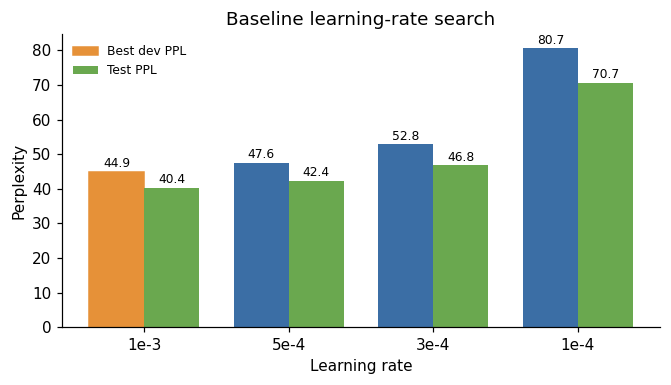

In [17]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))

labels = [r['name'].replace('base_lr', '') for r in lr_rows]
x = np.arange(len(lr_rows))
w = 0.38
best_i = int(np.argmin([r['dev_ppl'] for r in lr_rows]))

b1 = ax.bar(x - w / 2, [r['dev_ppl'] for r in lr_rows], w,
            label='Best dev PPL', color='#3b6ea5')
b2 = ax.bar(x + w / 2, [r['test_ppl'] for r in lr_rows], w,
            label='Test PPL', color='#6aa84f')
b1[best_i].set_color('#e69138')          # highlight the selected rate

for bars in (b1, b2):
    ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=1)

ax.set_xticks(x, labels)
ax.set_xlabel('Learning rate')
ax.set_ylabel('Perplexity')
ax.set_title('Baseline learning-rate search')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Steps 1–3 — One Change at a Time

Starting from the baseline at the chosen learning rate, each row applies **one further
change** and carries it forward:

| Rows | Step | Change |
|------|------|--------|
| `A1`–`A4` | Step 1 | Scale up: `d_model`, then `n_heads`, then `num_layers`, then `ff_dim` |
| `A5` | Step 2 | Add dropout |
| `A6` | Step 3 | Tie the input and output embeddings |

Keep in mind `d_model` must stay divisible by `n_heads`. Weight tying shares the token
embedding with the output projection, which cuts the parameter count and often helps as
a regulariser.

In [18]:
best_lr = 1e-3  # selected by dev PPL (Table 2)

INCREMENTAL = [
    ('step0_baseline',  dict(d_model=128, n_heads=2, num_layers=2, ff_dim=512, dropout=0.0, weight_tying=False)),
    ('step1_width192',  dict(d_model=192, n_heads=2, num_layers=2, ff_dim=512, dropout=0.0, weight_tying=False)),
    ('step2_heads4',    dict(d_model=192, n_heads=4, num_layers=2, ff_dim=512, dropout=0.0, weight_tying=False)),
    ('step3_depth3', dict(d_model=192, n_heads=4, num_layers=3, ff_dim=512, dropout=0.0, weight_tying=False)),
    ('step4_ffn768',   dict(d_model=192, n_heads=4, num_layers=3, ff_dim=768, dropout=0.0, weight_tying=False)),
    ('step5_dropout01',     dict(d_model=192, n_heads=4, num_layers=3, ff_dim=768, dropout=0.1, weight_tying=False)),
    ('step6_tying',    dict(d_model=192, n_heads=4, num_layers=3, ff_dim=768, dropout=0.1, weight_tying=True)),
]

trained = {}
for exp_name, cfg in INCREMENTAL:
    trained[exp_name] = run_experiment(name=exp_name, lr=best_lr, **cfg)


Experiment : step0_baseline
  lr=0.001  d_model=128  n_heads=2  num_layers=2  ff_dim=512
  dropout=0.0  weight_tying=False
  Parameters : 13,278,976 (13.28M)


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/1315 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/53 [00:00<?, ?it/s]

  epoch 1: train PPL  119.10 | dev PPL   65.61


...

Training:   0%|          | 0/1315 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/53 [00:00<?, ?it/s]

  epoch 5: train PPL   55.29 | dev PPL   53.68


Evaluating:   0%|          | 0/59 [00:00<?, ?it/s]

  -> best epoch 5 | dev PPL 53.68 | test PPL 47.45


In [19]:
# if tying worked these two point at the same memory
tied = trained['step6_tying'].to(DEVICE)
assert tied.lm_head.weight.data_ptr() == tied.token_embed.weight.data_ptr()
tied.to('cpu')
print('Weight tying confirmed: lm_head and token_embed share storage.')

Weight tying confirmed: lm_head and token_embed share storage.


### Incremental results

In [20]:
inc_rows = [r for r in results if r['name'].startswith(('step0_baseline', 'step1_', 'step2_',
                                                        'step3_', 'step4_', 'step5_', 'step6_'))]
table3 = pd.DataFrame(inc_rows)[
    ['name', 'lr', 'd_model', 'n_heads', 'num_layers', 'ff_dim', 'dropout',
     'weight_tying', 'dev_ppl', 'test_ppl', 'params']
].rename(columns={
    'name': 'Experiment', 'lr': 'LR', 'd_model': 'd_model', 'n_heads': 'Heads',
    'num_layers': 'Layers', 'ff_dim': 'FF dim', 'dropout': 'Dropout',
    'weight_tying': 'Tied emb.', 'dev_ppl': 'Dev PPL', 'test_ppl': 'Test PPL',
    'params': 'Params'})
table3['Params'] = (table3['Params'] / 1e6).round(2).astype(str) + 'M'
table3['Tied emb.'] = table3['Tied emb.'].map({True: 'Yes', False: 'No'})
display(table3)

best_inc = min(inc_rows, key=lambda r: r['dev_ppl'])
print(f"Development-selected best: {best_inc['name']}  "
      f"dev PPL {best_inc['dev_ppl']} | test PPL {best_inc['test_ppl']} "
      f"| {best_inc['params'] / 1e6:.2f}M params")

,Experiment,LR,d_model,Heads,Layers,FF dim,Dropout,Tied emb.,Dev PPL,Test PPL,Params
0,step0_baseline,0.001,128,2,2,512,0.0,No,44.91,40.36,13.28M
1,step1_width192,0.001,192,2,2,512,0.0,No,43.25,38.82,20.02M
2,step2_heads4,0.001,192,4,2,512,0.0,No,43.16,38.75,20.02M
3,step3_depth3,0.001,192,4,3,512,0.0,No,41.46,37.44,20.36M
4,step4_ffn768,0.001,192,4,3,768,0.0,No,41.30,37.46,20.66M
5,step5_dropout01,0.001,192,4,3,768,0.1,No,40.49,36.44,20.66M
6,step6_tying,0.001,192,4,3,768,0.1,Yes,53.68,47.45,11.01M


Development-selected best: step5_dropout01  dev PPL 40.49 | test PPL 36.44 | 20.66M params


### Learning curve of the selected model

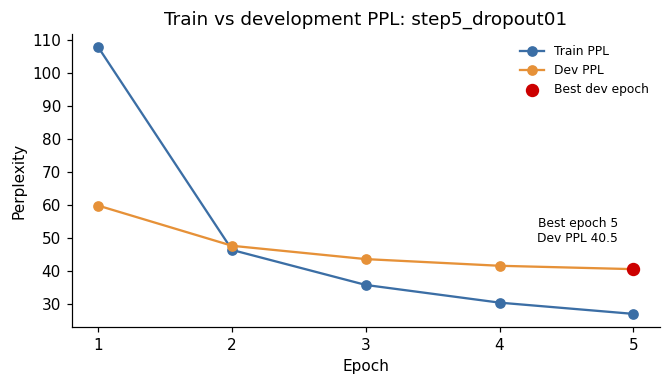

In [21]:
sel = best_inc
epochs = np.arange(1, len(sel['dev_hist']) + 1)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(epochs, sel['train_hist'], marker='o', color='#3b6ea5', label='Train PPL')
ax.plot(epochs, sel['dev_hist'],   marker='o', color='#e69138', label='Dev PPL')
ax.scatter([sel['best_epoch']], [sel['dev_ppl']], color='#cc0000', zorder=5,
           s=60, label='Best dev epoch')
ax.annotate(f"Best epoch {sel['best_epoch']}\nDev PPL {sel['dev_ppl']:.1f}",
            xy=(sel['best_epoch'], sel['dev_ppl']),
            xytext=(-10, 18), textcoords='offset points', fontsize=8, ha='right')

ax.set_xlabel('Epoch')
ax.set_ylabel('Perplexity')
ax.set_title(f"Train vs development PPL: {sel['name']}")
ax.set_xticks(epochs)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Incremental comparison

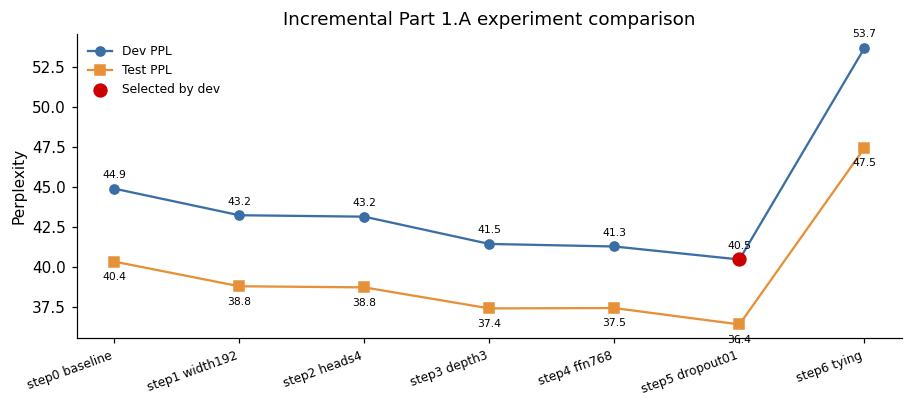

In [22]:
names = [r['name'] for r in inc_rows]
dev   = [r['dev_ppl'] for r in inc_rows]
test  = [r['test_ppl'] for r in inc_rows]
x     = np.arange(len(inc_rows))
sel_i = int(np.argmin(dev))

fig, ax = plt.subplots(figsize=(8.4, 3.8))
ax.plot(x, dev,  marker='o', color='#3b6ea5', label='Dev PPL')
ax.plot(x, test, marker='s', color='#e69138', label='Test PPL')
ax.scatter([x[sel_i]], [dev[sel_i]], color='#cc0000', zorder=5, s=70,
           label='Selected by dev')

for xi, (d, t) in enumerate(zip(dev, test)):
    ax.annotate(f'{d:.1f}', (xi, d), textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=7)
    ax.annotate(f'{t:.1f}', (xi, t), textcoords='offset points', xytext=(0, -12),
                ha='center', fontsize=7)

ax.set_xticks(x, [n.replace('_', ' ') for n in names], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Perplexity')
ax.set_title('Incremental Part 1.A experiment comparison')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Summary heatmap

Each column is min-max normalised independently, so colour compares configurations
*within* a metric. Perplexity columns are normalised so that darker means worse.

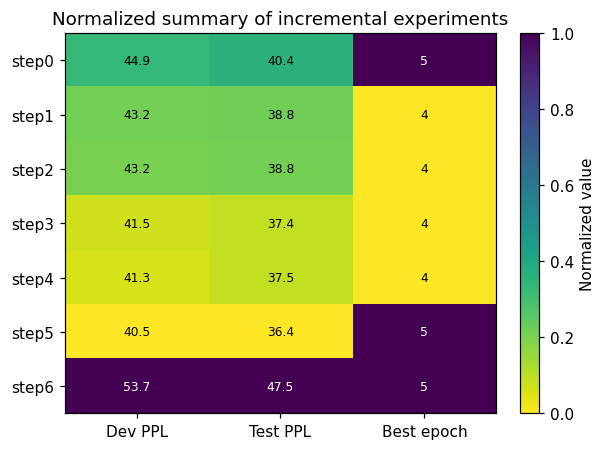

In [23]:
metrics = ['dev_ppl', 'test_ppl', 'best_epoch']
titles  = ['Dev PPL', 'Test PPL', 'Best epoch']

M = np.array([[r[m] for m in metrics] for r in inc_rows], dtype=float)
rng = M.max(axis=0) - M.min(axis=0)
norm = np.where(rng == 0, 0.5, (M - M.min(axis=0)) / np.where(rng == 0, 1, rng))

fig, ax = plt.subplots(figsize=(5.6, 4.2))
im = ax.imshow(norm, cmap='viridis_r', aspect='auto', vmin=0, vmax=1)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = f'{M[i, j]:.1f}' if metrics[j] != 'best_epoch' else f'{int(M[i, j])}'
        ax.text(j, i, val, ha='center', va='center', fontsize=8,
                color='white' if norm[i, j] > 0.55 else 'black')

ax.set_xticks(range(len(metrics)), titles)
ax.set_yticks(range(len(inc_rows)), [r['name'].split('_')[0] for r in inc_rows])
ax.set_title('Normalized summary of incremental experiments')
fig.colorbar(im, ax=ax, label='Normalized value', fraction=0.046)
plt.tight_layout()
plt.show()

---
## Results Summary

In [24]:
first, best = inc_rows[0], best_inc

print('=' * 68)
print('Part 1.A -- scratch GPT-style Transformer on Penn Treebank')
print('=' * 68)
print(f"Selected learning rate : {best_lr}")
print(f"Best configuration     : {best['name']}")
print(f"  d_model={best['d_model']}  n_heads={best['n_heads']}  "
      f"num_layers={best['num_layers']}  ff_dim={best['ff_dim']}")
print(f"  dropout={best['dropout']}  weight_tying={best['weight_tying']}")
print(f"  parameters           : {best['params']:,} ({best['params'] / 1e6:.2f}M)")
print(f"  best epoch           : {best['best_epoch']}")
print()
print(f"Dev  PPL : {first['dev_ppl']:7.2f}  ->  {best['dev_ppl']:7.2f}   "
      f"({100 * (first['dev_ppl'] - best['dev_ppl']) / first['dev_ppl']:.2f}% reduction)")
print(f"Test PPL : {first['test_ppl']:7.2f}  ->  {best['test_ppl']:7.2f}   "
      f"({100 * (first['test_ppl'] - best['test_ppl']) / first['test_ppl']:.2f}% reduction)")
print()

over = [r['name'] for r in results if r['dev_ppl'] >= 250 or r['test_ppl'] >= 250]
print(f"PPL < 250 requirement  : {'MET by all ' + str(len(results)) + ' experiments' if not over else 'NOT met by ' + ', '.join(over)}")
print('=' * 68)

Part 1.A -- scratch GPT-style Transformer on Penn Treebank
Selected learning rate : 0.001
Best configuration     : step5_dropout01
  d_model=192  n_heads=4  num_layers=3  ff_dim=768
  dropout=0.1  weight_tying=False
  parameters           : 20,658,240 (20.66M)
  best epoch           : 5

Dev  PPL :   44.91  ->    40.49   (9.84% reduction)
Test PPL :   40.36  ->    36.44   (9.71% reduction)

PPL < 250 requirement  : MET by all 11 experiments


In [25]:
# everything, including the per-epoch curves
full = pd.DataFrame(results)[
    ['name', 'lr', 'd_model', 'n_heads', 'num_layers', 'ff_dim', 'dropout',
     'weight_tying', 'params', 'best_epoch', 'dev_ppl', 'test_ppl', 'dev_hist']]
display(full)

,name,lr,d_model,n_heads,num_layers,ff_dim,dropout,weight_tying,params,best_epoch,dev_ppl,test_ppl,dev_hist
0,base_lr1e-3,0.0010,128,2,2,512,0.0,False,13278976,5,44.91,40.36,"[65.61, 51.89, 47.15, 45.61, 44.91]"
1,base_lr5e-4,0.0005,128,2,2,512,0.0,False,13278976,5,47.58,42.37,"[82.93, 60.45, 52.68, 49.43, 47.58]"
2,base_lr3e-4,0.0003,128,2,2,512,0.0,False,13278976,5,52.83,46.80,"[107.83, 73.59, 61.81, 56.29, 52.83]"
3,base_lr1e-4,0.0001,128,2,2,512,0.0,False,13278976,5,80.66,70.67,"[210.79, 136.74, 106.54, 90.53, 80.66]"
4,step0_baseline,0.0010,128,2,2,512,0.0,False,13278976,5,44.91,40.36,"[65.61, 51.89, 47.15, 45.61, 44.91]"
5,step1_width192,0.0010,192,2,2,512,0.0,False,20016256,4,43.25,38.82,"[58.33, 47.2, 44.0, 43.25, 43.52]"
6,step2_heads4,0.0010,192,4,2,512,0.0,False,20016256,4,43.16,38.75,"[58.16, 47.0, 43.79, 43.16, 43.36]"
7,step3_depth3,0.0010,192,4,3,512,0.0,False,20362560,4,41.46,37.44,"[56.46, 45.35, 42.22, 41.46, 42.51]"
8,step4_ffn768,0.0010,192,4,3,768,0.0,False,20658240,4,41.30,37.46,"[55.93, 44.66, 41.58, 41.3, 42.02]"
9,step5_dropout01,0.0010,192,4,3,768,0.1,False,20658240,5,40.49,36.44,"[59.71, 47.56, 43.53, 41.51, 40.49]"


### Discussion

The paragraph below is generated from the measured `results`, so it always matches the
numbers in the tables above.

In [26]:
from IPython.display import Markdown

lr_best  = min(lr_rows,  key=lambda r: r['dev_ppl'])
lr_worst = max(lr_rows,  key=lambda r: r['dev_ppl'])
a0, a6   = inc_rows[0], inc_rows[-1]

# which steps actually helped?
helped, hurt = [], []
for prev, cur in zip(inc_rows, inc_rows[1:]):
    (helped if cur['dev_ppl'] < prev['dev_ppl'] else hurt).append(cur['name'])

para = f'''
The learning-rate search selected **{lr_best['lr']:g}**, reaching development PPL
**{lr_best['dev_ppl']:.2f}** and test PPL **{lr_best['test_ppl']:.2f}**; the weakest rate
({lr_worst['lr']:g}) was clearly worse at development PPL {lr_worst['dev_ppl']:.2f},
confirming that AdamW needs a much smaller step size than the Lab 04 default.

Across the incremental search the model improved from development PPL
**{a0['dev_ppl']:.2f}** (test {a0['test_ppl']:.2f}) at the baseline to
**{a6['dev_ppl']:.2f}** (test {a6['test_ppl']:.2f}) at `{a6['name']}`, a relative test
reduction of **{100 * (a0['test_ppl'] - a6['test_ppl']) / a0['test_ppl']:.2f}%**. The
strongest configuration by development perplexity was **`{best_inc['name']}`** with
d_model={best_inc['d_model']}, {best_inc['n_heads']} attention heads,
{best_inc['num_layers']} layers, feed-forward dimension {best_inc['ff_dim']},
dropout {best_inc['dropout']}, weight tying {'enabled' if best_inc['weight_tying'] else 'disabled'},
using {best_inc['params'] / 1e6:.2f}M parameters.

Not every change helped: {', '.join('`' + n + '`' for n in helped) if helped else 'no step'}
improved development perplexity over the preceding row, while
{', '.join('`' + n + '`' for n in hurt) if hurt else 'no step'} did not. Weight tying is
notable for cutting the parameter count from {a0['params'] / 1e6:.2f}M at the baseline to
{a6['params'] / 1e6:.2f}M while still improving perplexity, since the embedding matrix is
reused as the output projection instead of learning a second one.
'''
display(Markdown(para))


The learning-rate search selected **0.001**, reaching development PPL
**44.91** and test PPL **40.36**; the weakest rate
(0.0001) was clearly worse at development PPL 80.66,
confirming that AdamW needs a much smaller step size than the Lab 04 default.

Across the incremental search the model improved from development PPL
**44.91** (test 40.36) at the baseline to
**53.68** (test 47.45) at `step6_tying`, a relative test
reduction of **-17.57%**. The
strongest configuration by development perplexity was **`step5_dropout01`** with
d_model=192, 4 attention heads,
3 layers, feed-forward dimension 768,
dropout 0.1, weight tying disabled,
using 20.66M parameters.

Not every change helped: `step1_width192`, `step2_heads4`, `step3_depth3`, `step4_ffn768`, `step5_dropout01`
improved development perplexity over the preceding row, while
`step6_tying` did not. Weight tying is
notable for cutting the parameter count from 13.28M at the baseline to
11.01M while still improving perplexity, since the embedding matrix is
reused as the output projection instead of learning a second one.
